In [1]:
# -------------------- IMPORT LIBRARIES --------------------
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

In [18]:
# -------------------- DATA LOADING --------------------
df = pd.read_csv("rounded_hours_student_scores.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   Hours  Scores
0    1.1      41
1    1.2      40
2    1.4      38
3    1.5      39
4    1.6      36

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   60 non-null     float64
 1   Scores  60 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.1 KB
None

Missing Values:
Hours     0
Scores    0
dtype: int64


In [19]:
# -------------------- DATA PREPROCESSING --------------------
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [20]:
# Replace column names below if your dataset differs

X = df[['Hours']]
y = df['Scores']

In [21]:
# -------------------- TRAIN TEST SPLIT --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# -------------------- ML PIPELINE --------------------
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [23]:
# -------------------- MODEL TRAINING --------------------
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [24]:
# -------------------- PREDICTIONS --------------------
y_pred = pipeline.predict(X_test)

In [25]:
# -------------------- EVALUATION --------------------
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


--- Model Evaluation ---
MSE : 15.667805255500062
RMSE: 3.958257856115498
R2 Score: 0.5809502309078735


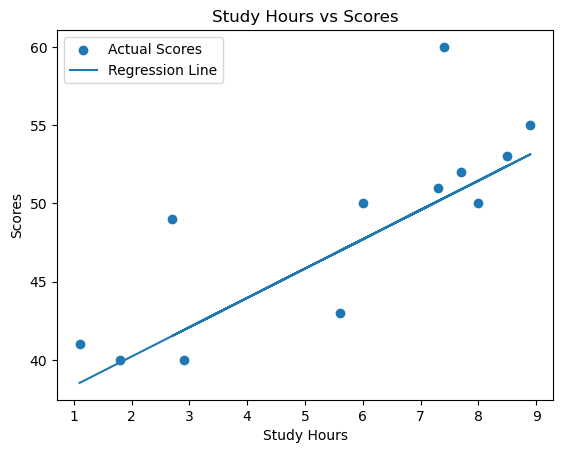

In [26]:
# -------------------- VISUALIZATION --------------------
plt.scatter(X_test, y_test, label="Actual Scores")
plt.plot(X_test, y_pred, label="Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Scores")
plt.title("Study Hours vs Scores")
plt.legend()
plt.show()

In [28]:
# -------------------- USER PREDICTION --------------------
hours = float(input("Enter Study Hours: "))

input_data = pd.DataFrame({
    'Hours': [hours]
})

pred_score = pipeline.predict(input_data)

print("Predicted Score:", round(pred_score[0], 2))

Enter Study Hours:  8


Predicted Score: 51.45
